In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/Pothole Detection.v4i.yolov8.zip" -d /content/dataset

In [3]:
!find /content/dataset -maxdepth 3

/content/dataset
/content/dataset/train
/content/dataset/train/images
/content/dataset/train/images/1764136926643_aug_0_jpg.rf.1923a3321278470bc7bc44bc015420cf.jpg
/content/dataset/train/images/IMG_20250425_171952_aug_2_jpg.rf.0ff89d25bd1bc7441282bcc2780c94d9.jpg
/content/dataset/train/images/IMG_20250516_181129_aug_1_jpg.rf.1771fcc65b2ffec9134ff32f175b2591.jpg
/content/dataset/train/images/1764136926704_aug_2_jpg.rf.a06c446962d361f52567296566b46c79.jpg
/content/dataset/train/images/IMG_20250425_172801_aug_4_jpg.rf.6cc0140c64478be48c3c124d7df48d36.jpg
/content/dataset/train/images/IMG_20250425_172801_aug_1_jpg.rf.62105cf638933512705cf0ccf0fa9e67.jpg
/content/dataset/train/images/1764136926727_aug_2_jpg.rf.9ea2db935176f0b59398f1ad6553afe5.jpg
/content/dataset/train/images/1764136926692_aug_4_jpg.rf.1a0619169e9eb7f7d4a7967a50b0ecbe.jpg
/content/dataset/train/images/IMG_20250425_171741_aug_0_jpg.rf.f2374f04fb4fb0ffbbd6f0208b334b99.jpg
/content/dataset/train/images/IMG_20250516_180821_aug_

In [4]:
%%writefile /content/dataset/data.yaml
path: /content/dataset

train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: pothole

Overwriting /content/dataset/data.yaml


In [5]:
!cat /content/dataset/data.yaml

path: /content/dataset

train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: pothole


In [6]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.1 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="Pothole_Project",
    name="YOLOv8"
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, for

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba518558560>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
import os

for root, dirs, files in os.walk("/content"):
    if "best.pt" in files:
        print(os.path.join(root, "best.pt"))

/content/runs/detect/Pothole_Project/YOLOv8/weights/best.pt


In [9]:
import os

for file in os.listdir("/content/runs/detect/Pothole_Project/YOLOv8"):
    print(file)

val_batch0_labels.jpg
BoxF1_curve.png
train_batch1.jpg
train_batch1892.jpg
results.png
val_batch0_pred.jpg
BoxR_curve.png
train_batch0.jpg
weights
train_batch1890.jpg
train_batch2.jpg
train_batch1891.jpg
args.yaml
BoxPR_curve.png
labels.jpg
confusion_matrix.png
BoxP_curve.png
results.csv
confusion_matrix_normalized.png


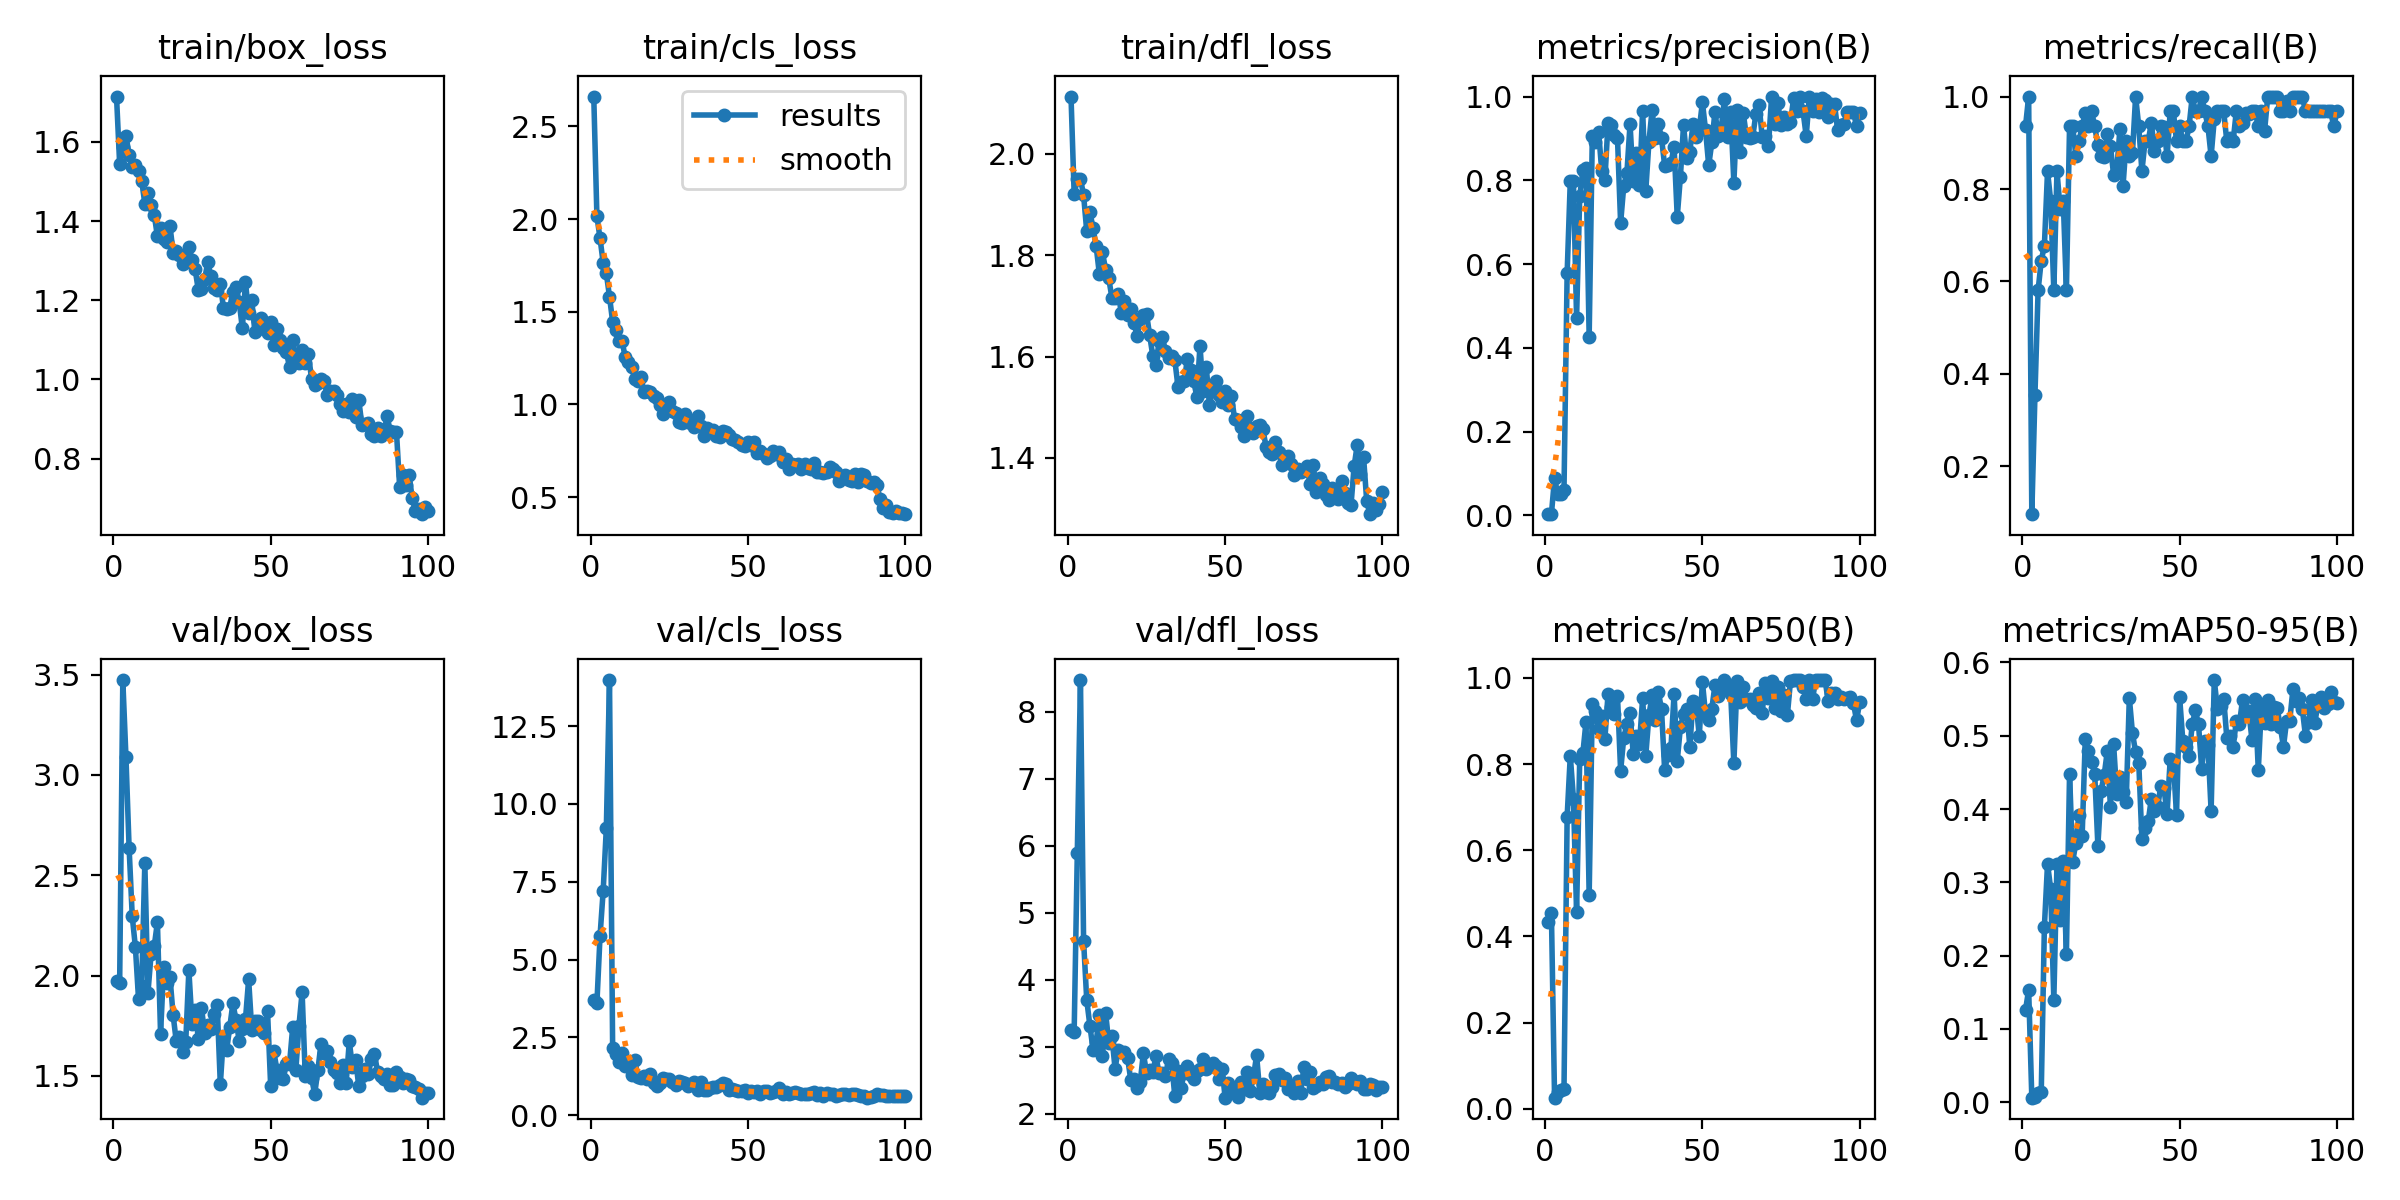

In [10]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/Pothole_Project/YOLOv8/results.png"))

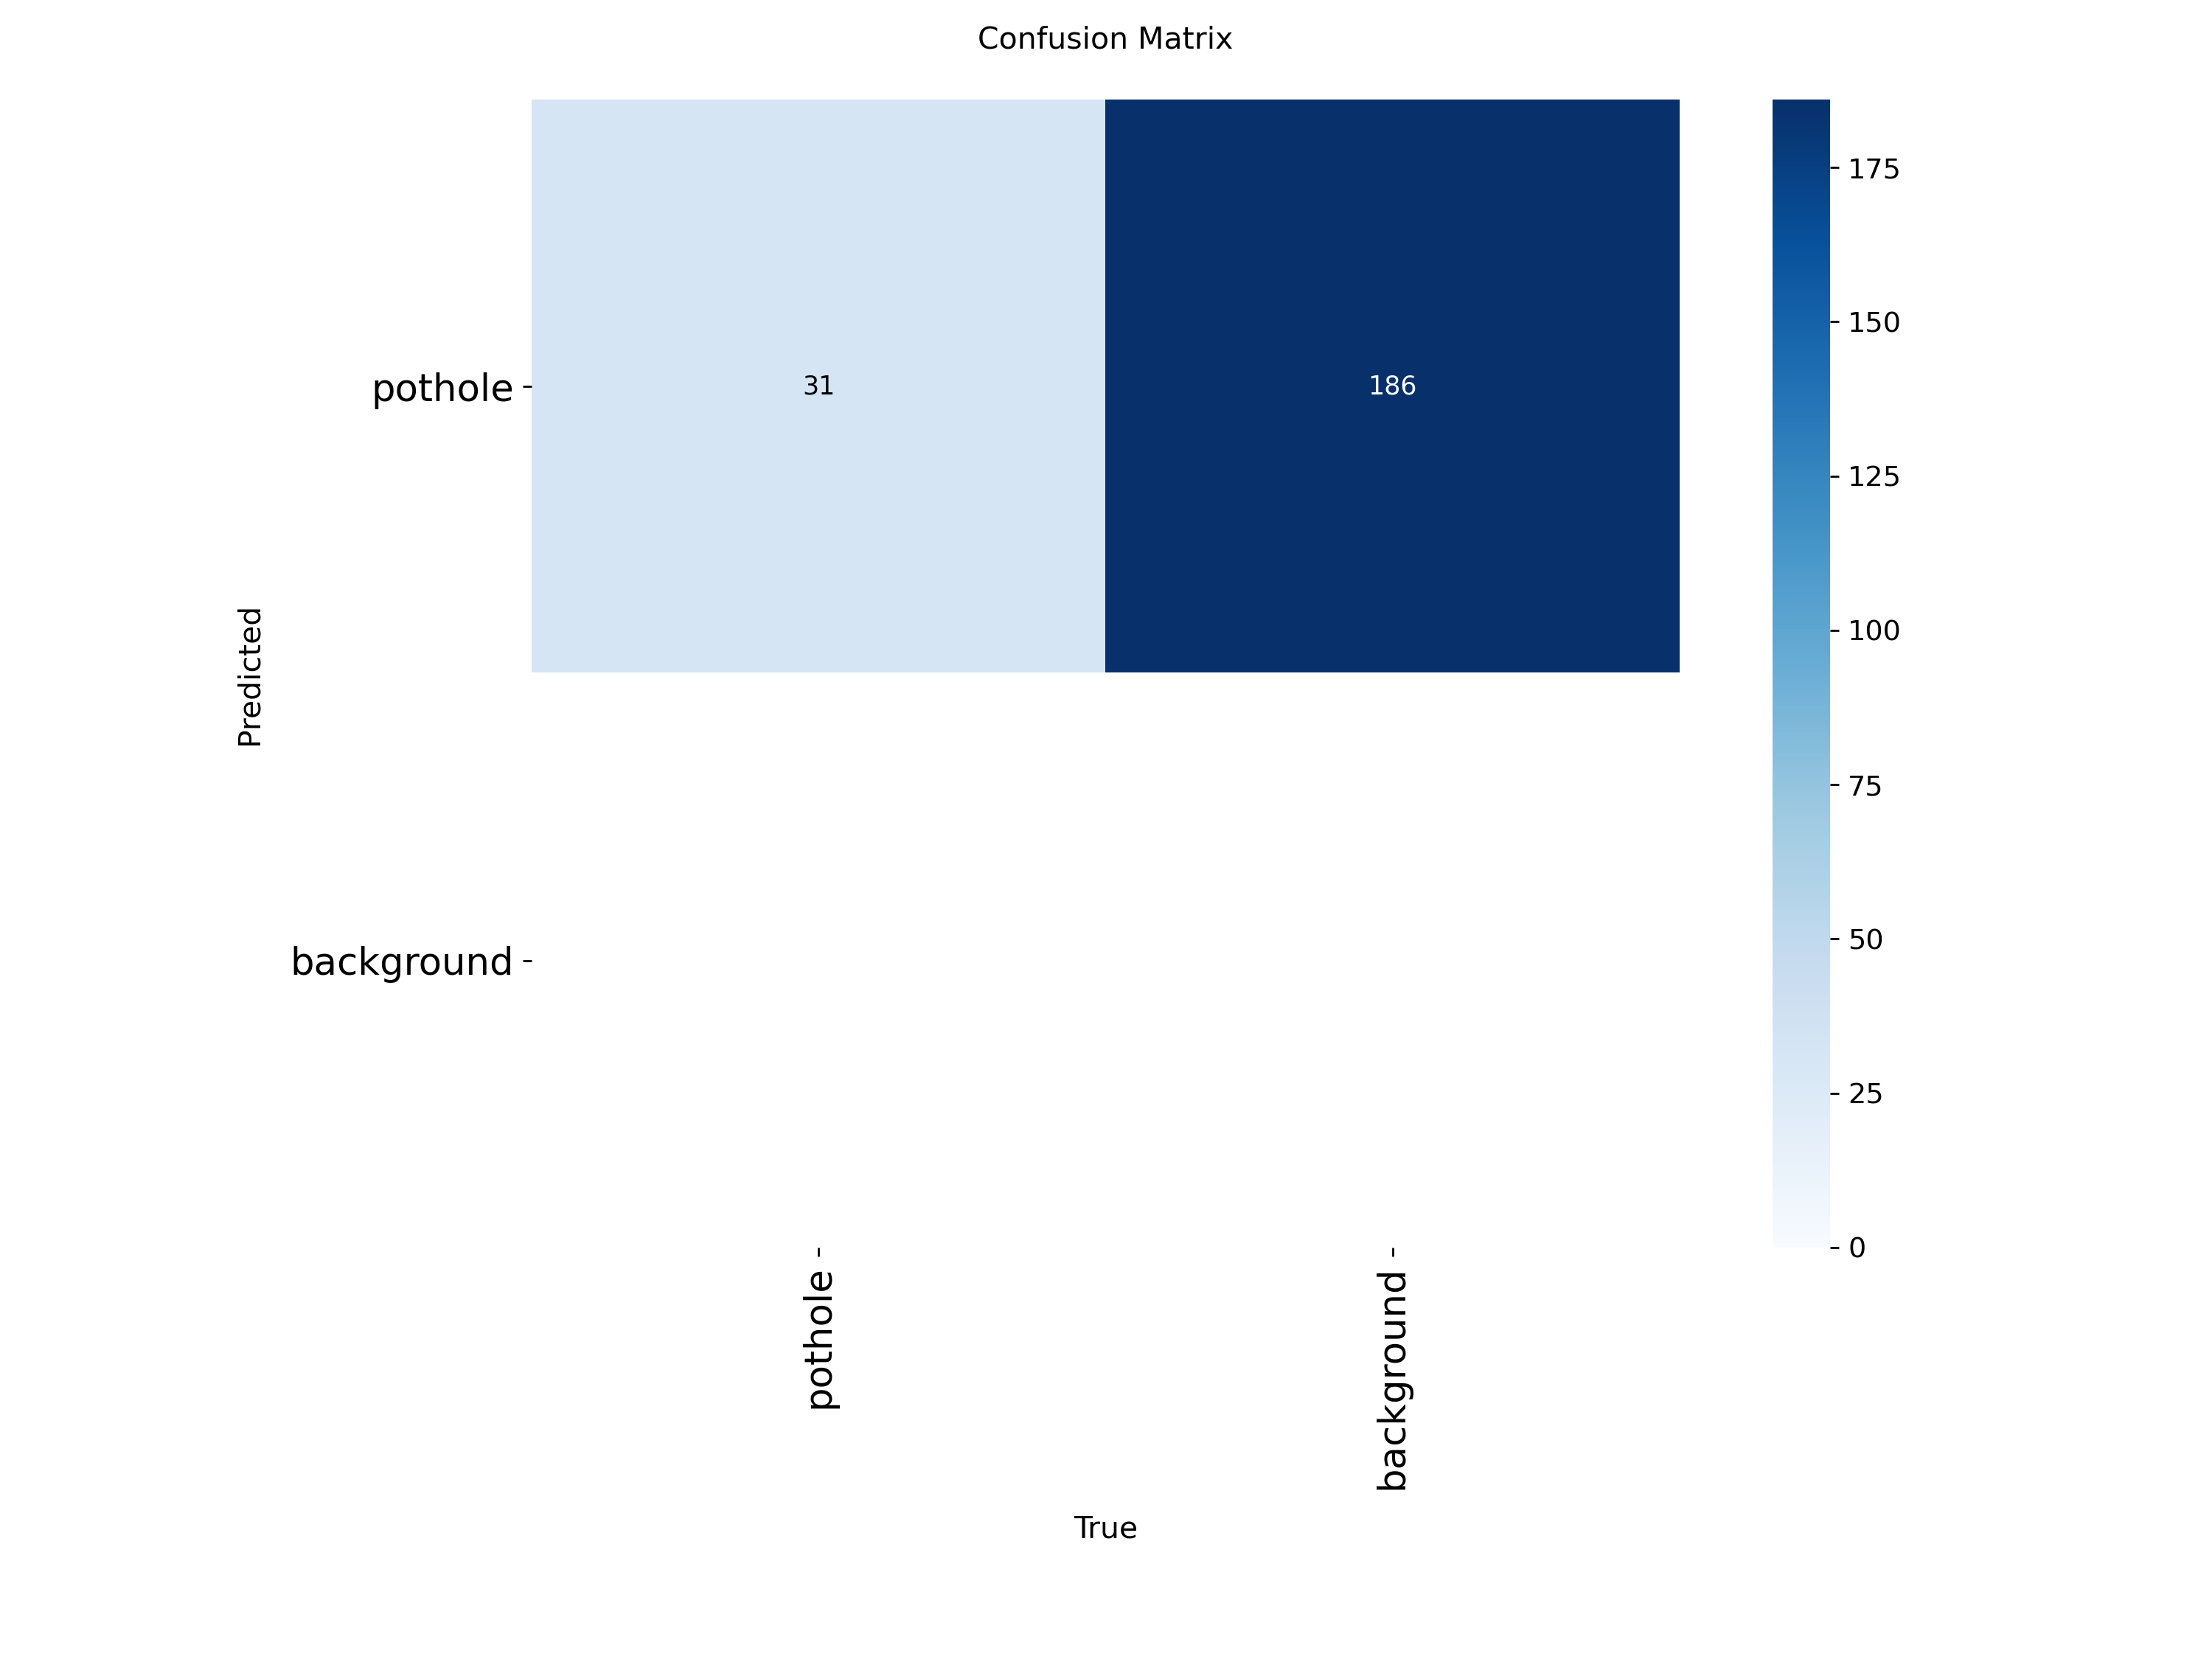

In [11]:
display(Image(filename="/content/runs/detect/Pothole_Project/YOLOv8/confusion_matrix.png"))

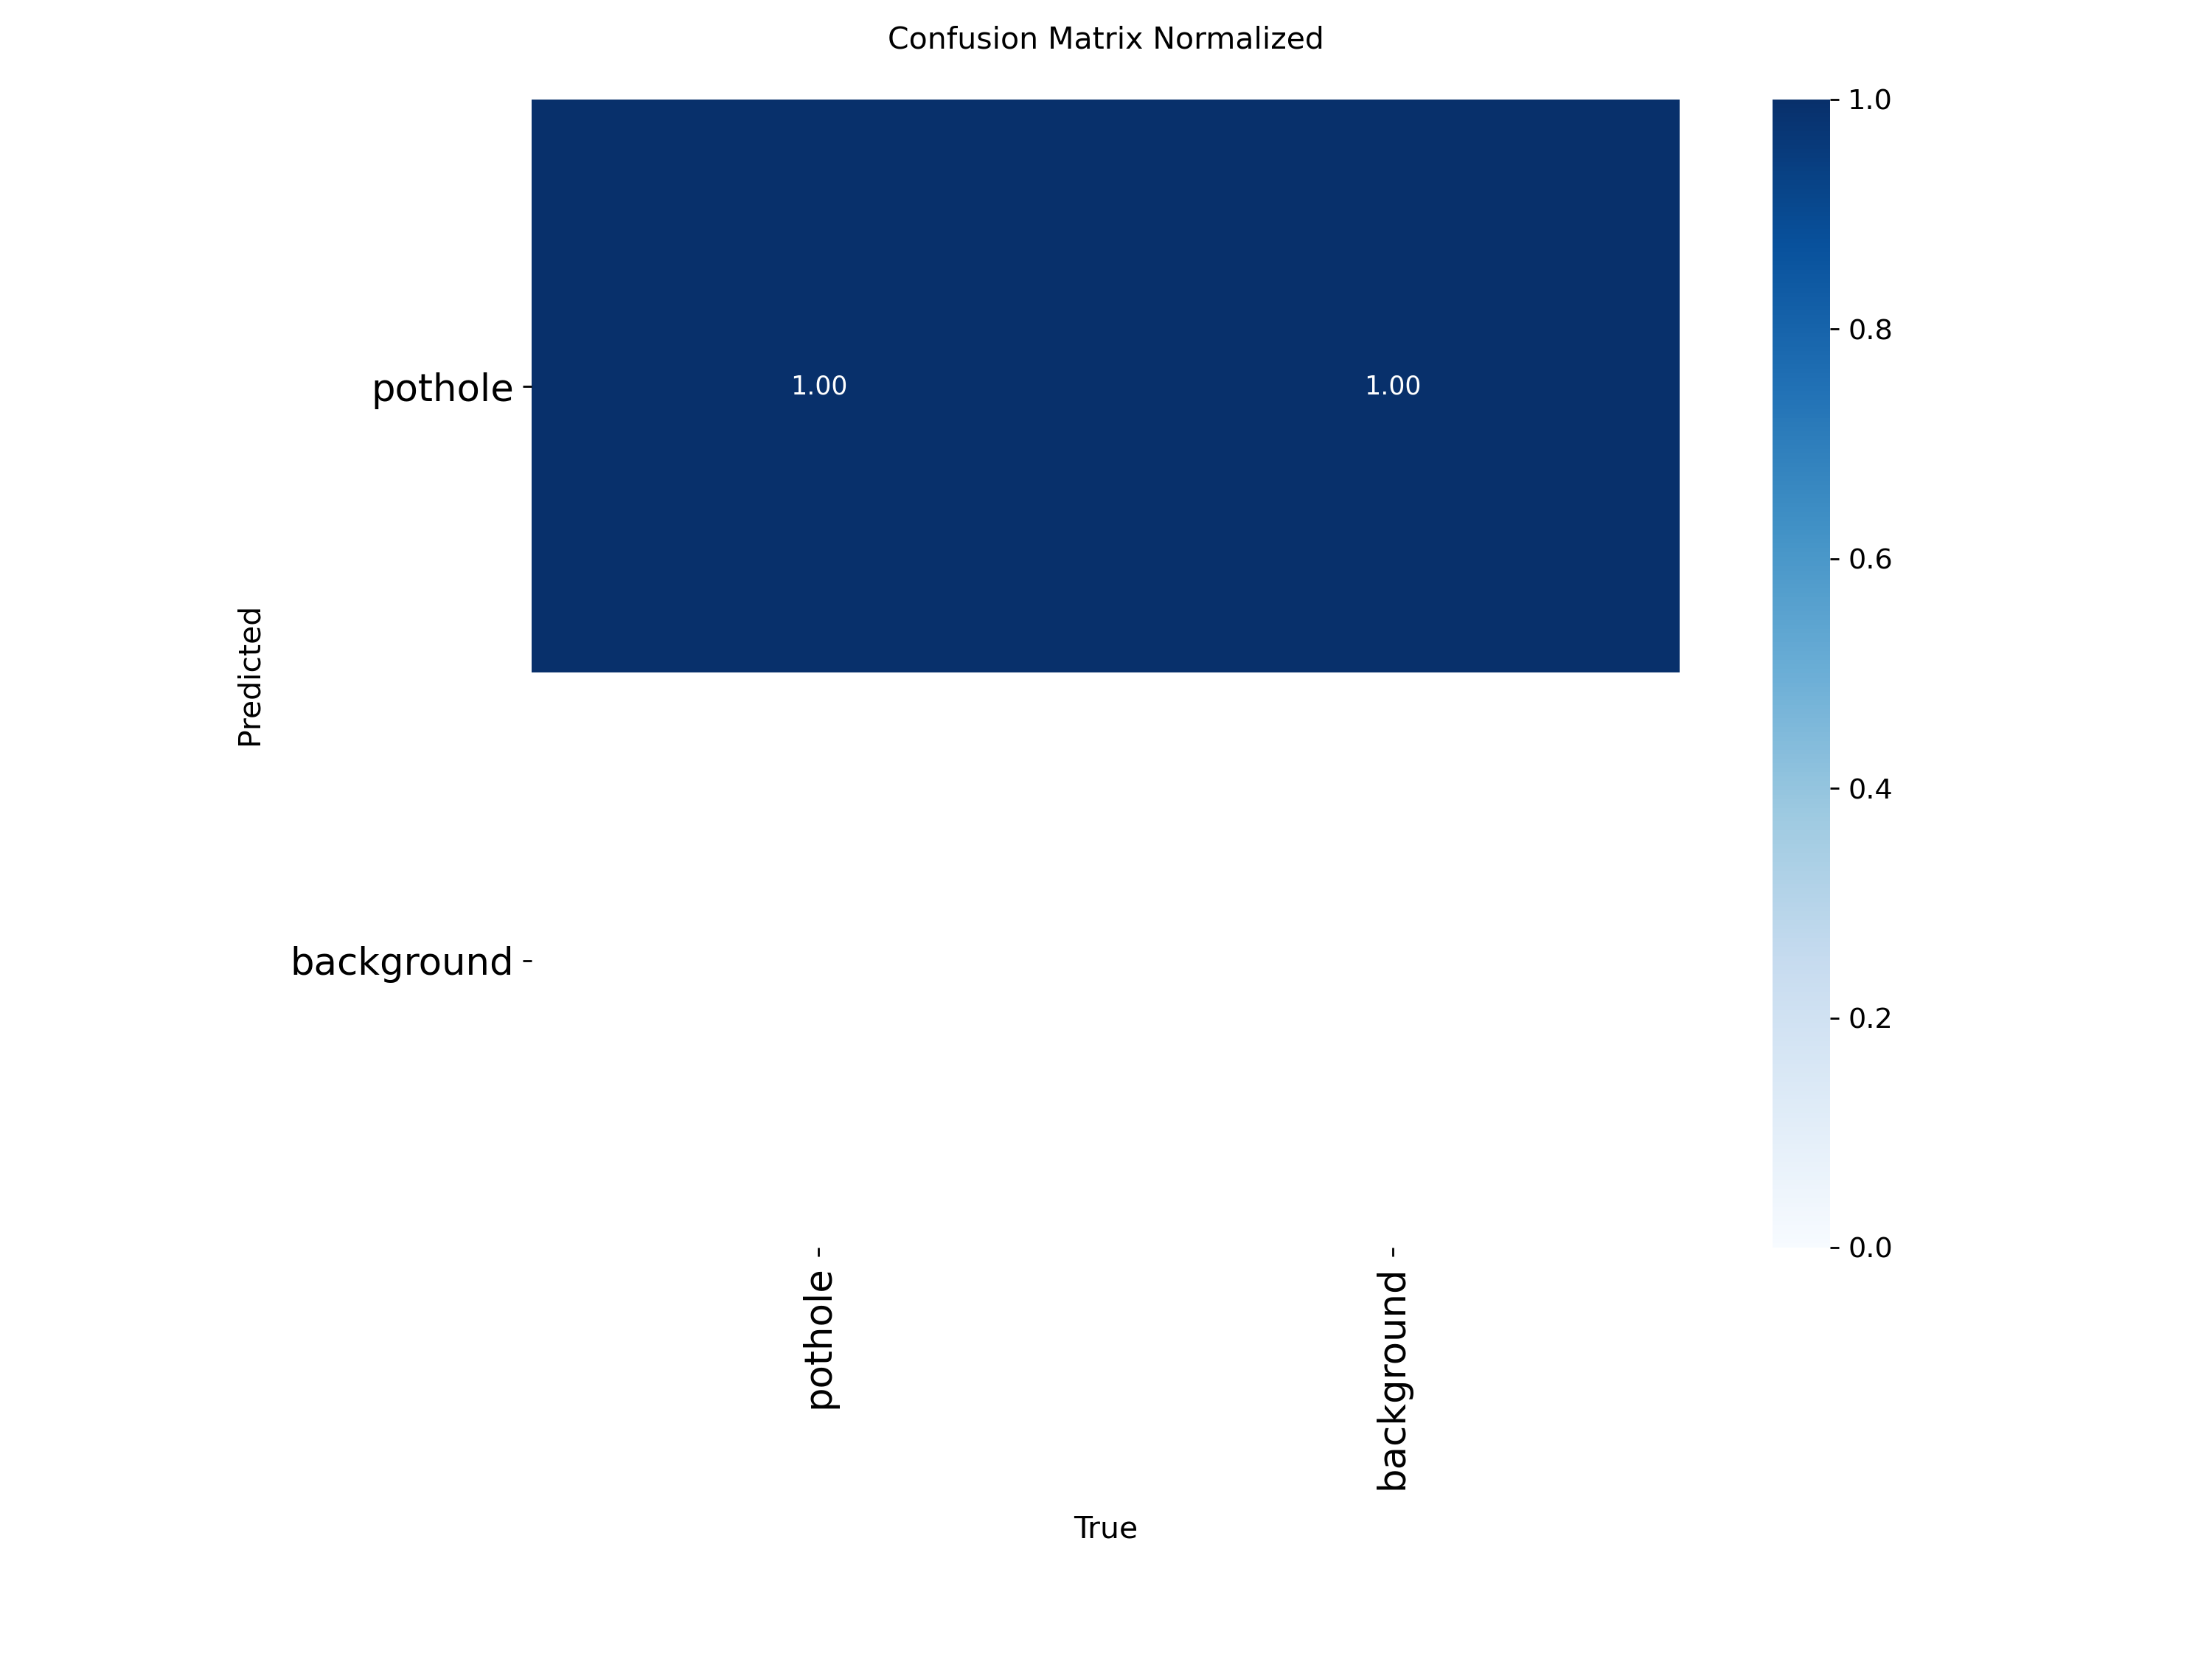

In [12]:
display(Image(filename="/content/runs/detect/Pothole_Project/YOLOv8/confusion_matrix_normalized.png"))

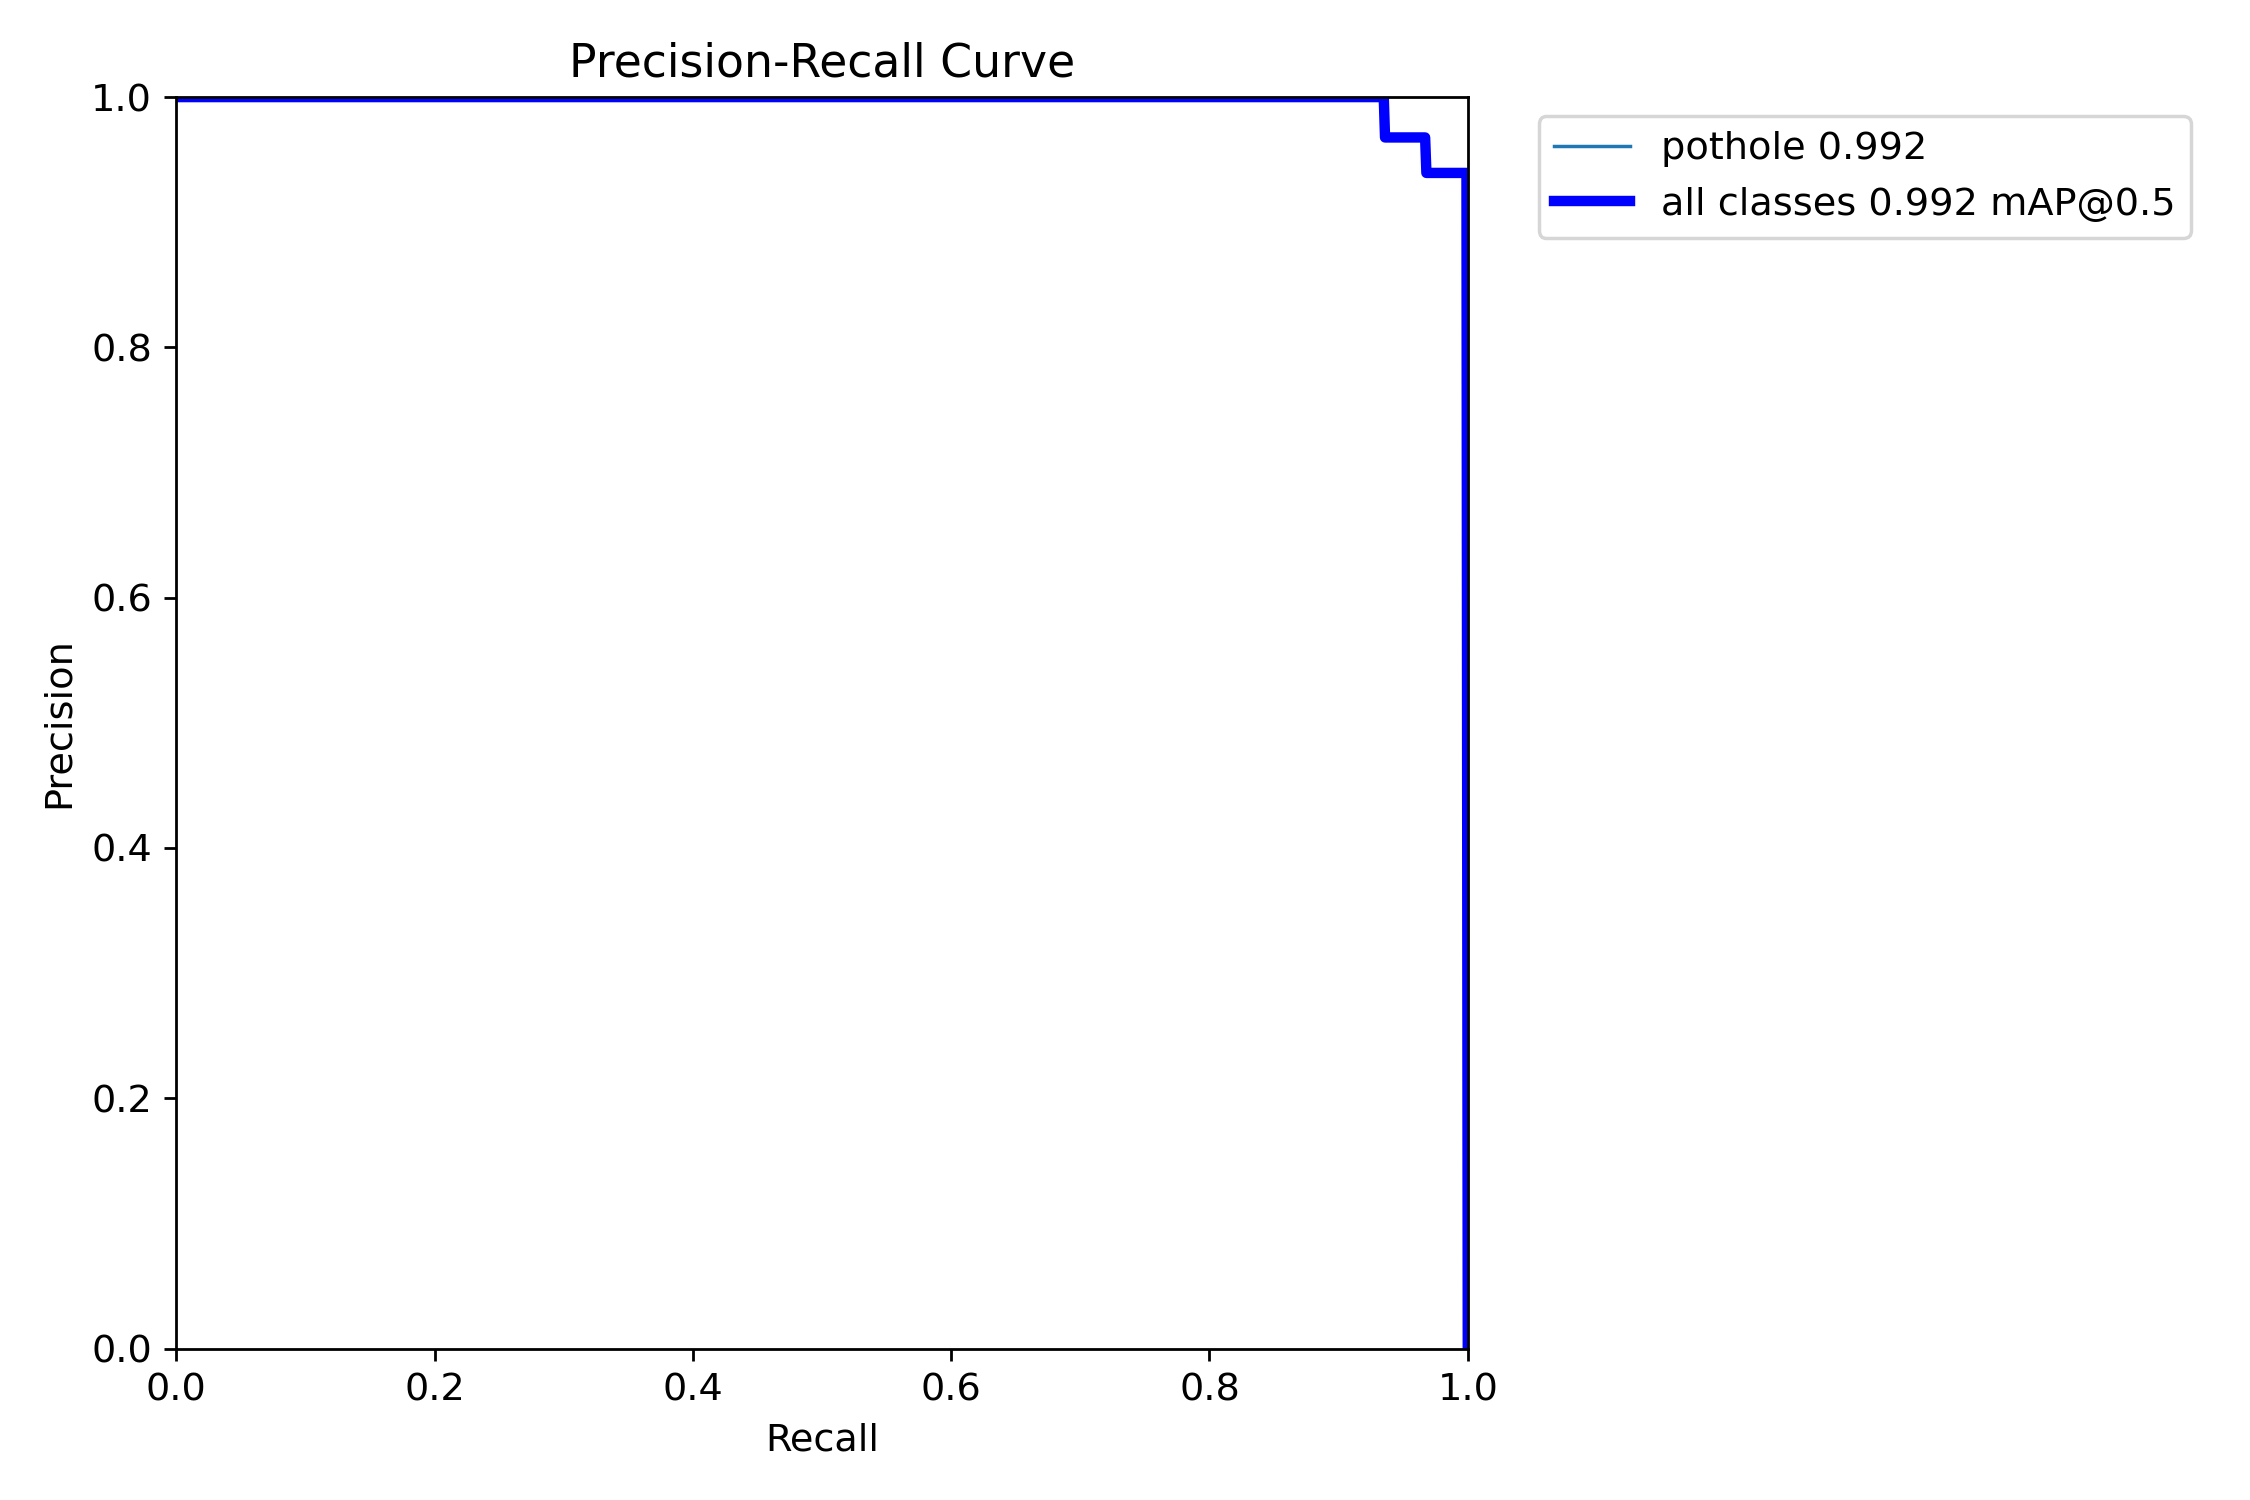

In [13]:
display(Image(filename="/content/runs/detect/Pothole_Project/YOLOv8/BoxPR_curve.png"))

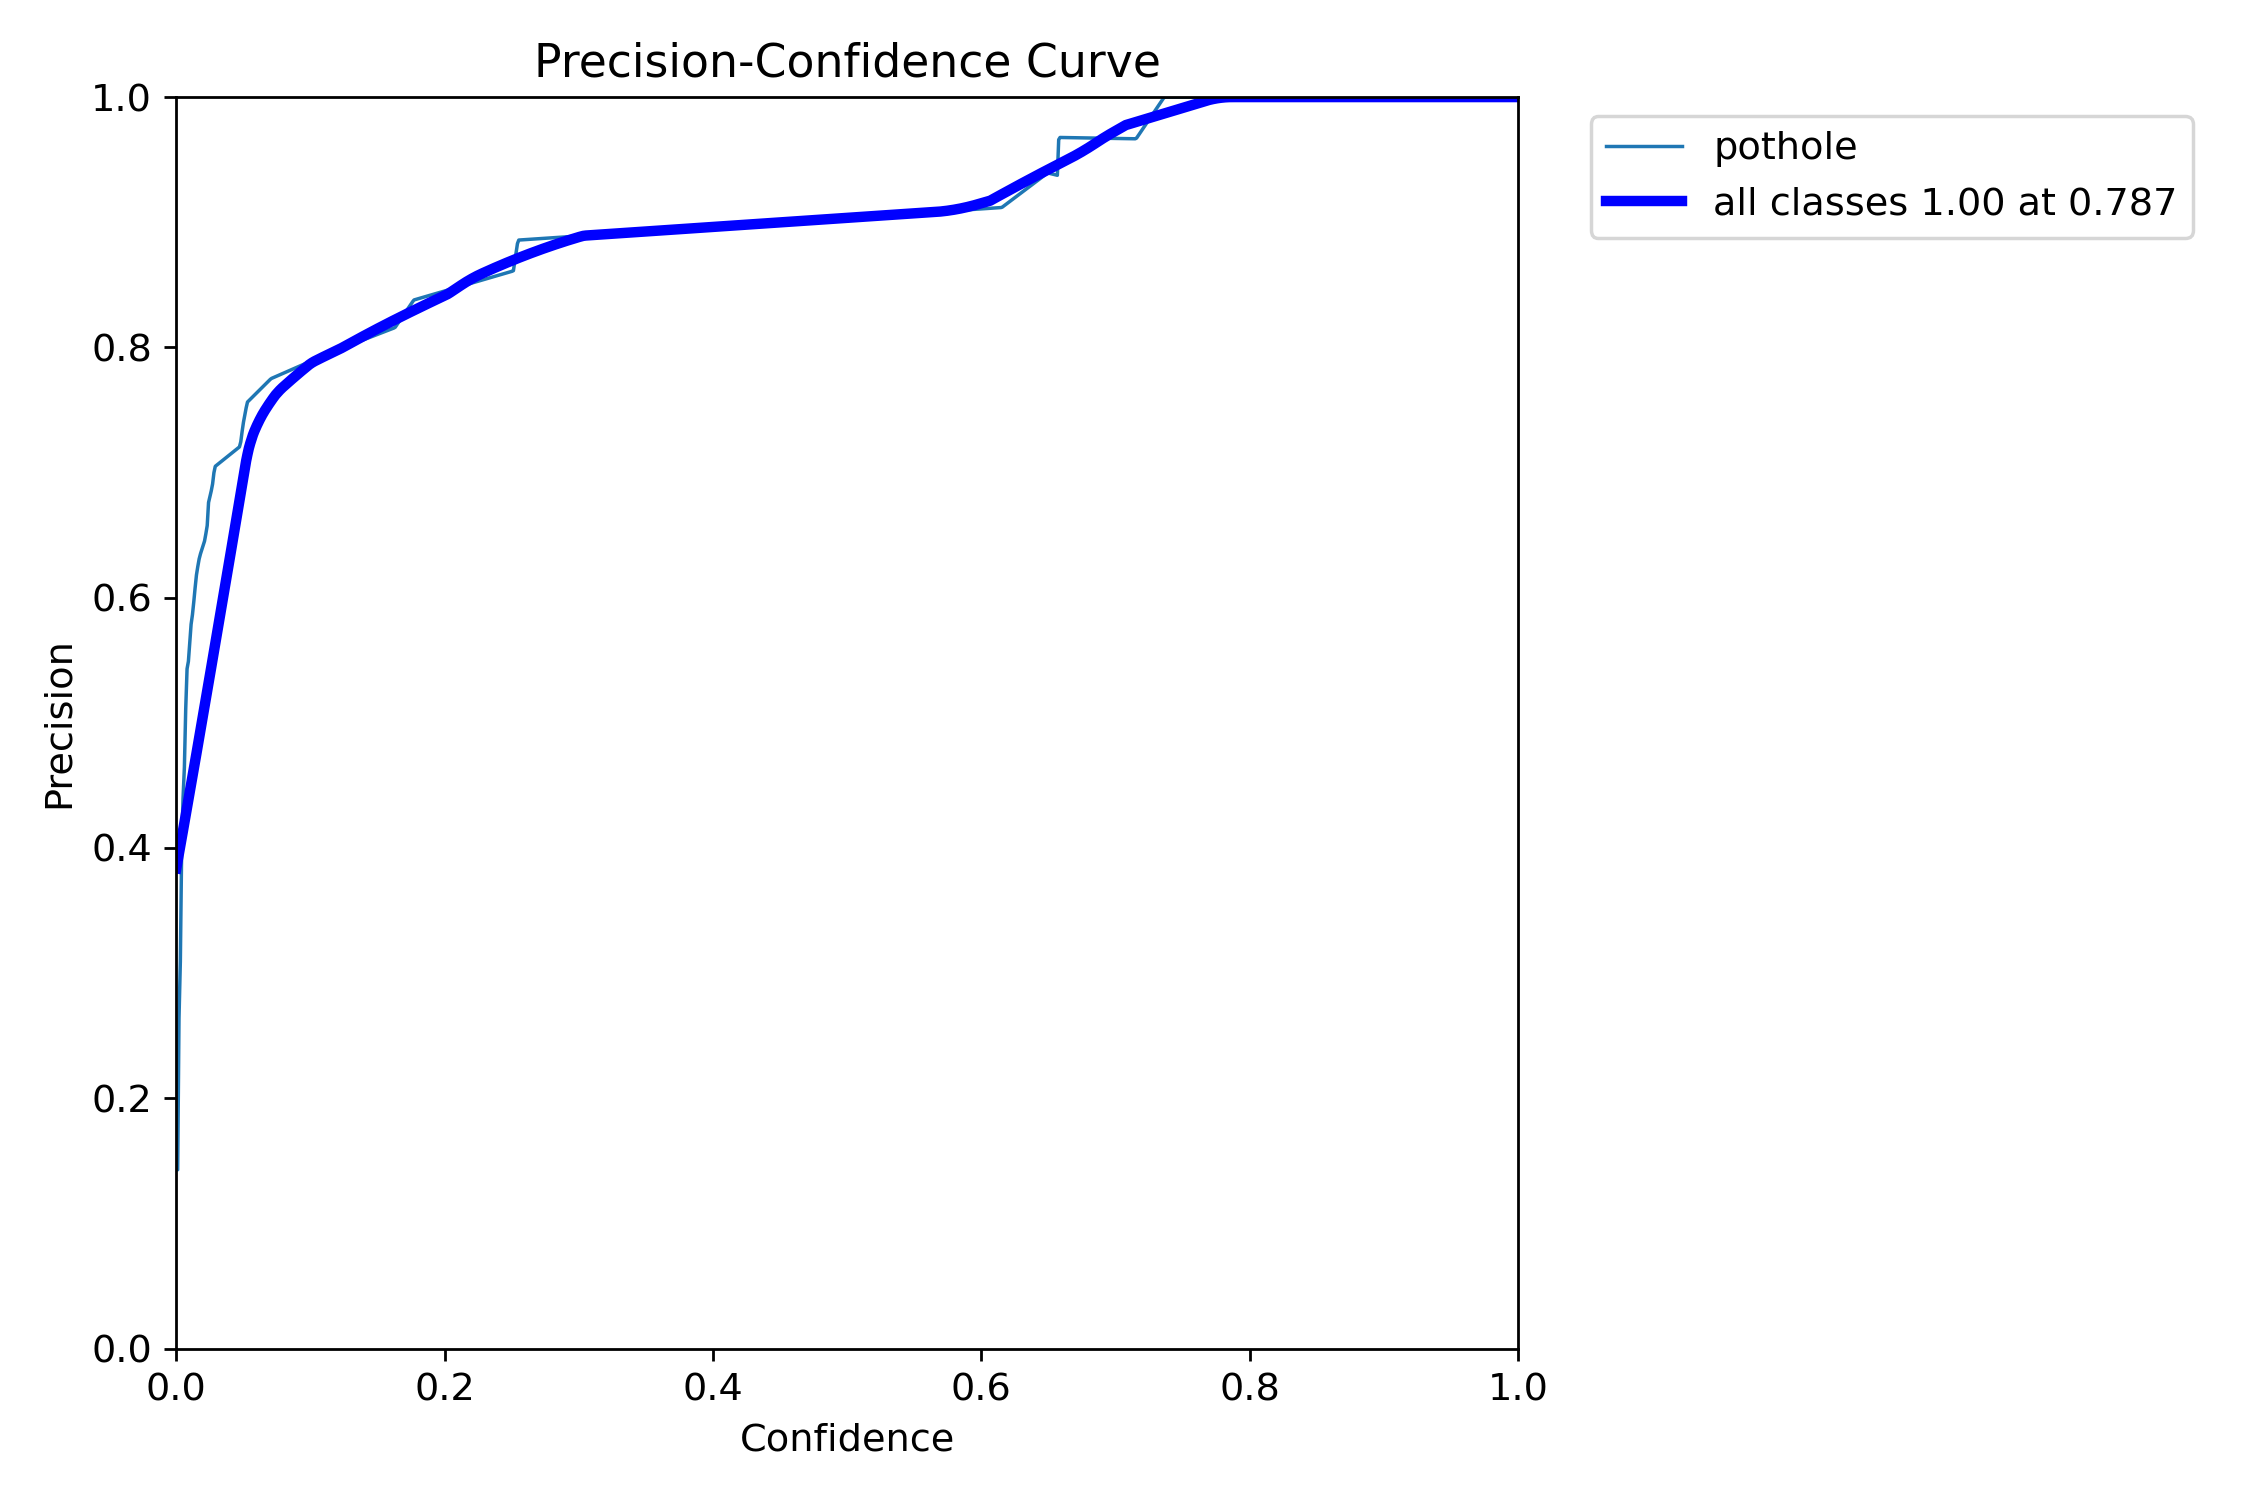

In [14]:
display(Image(filename="/content/runs/detect/Pothole_Project/YOLOv8/BoxP_curve.png"))

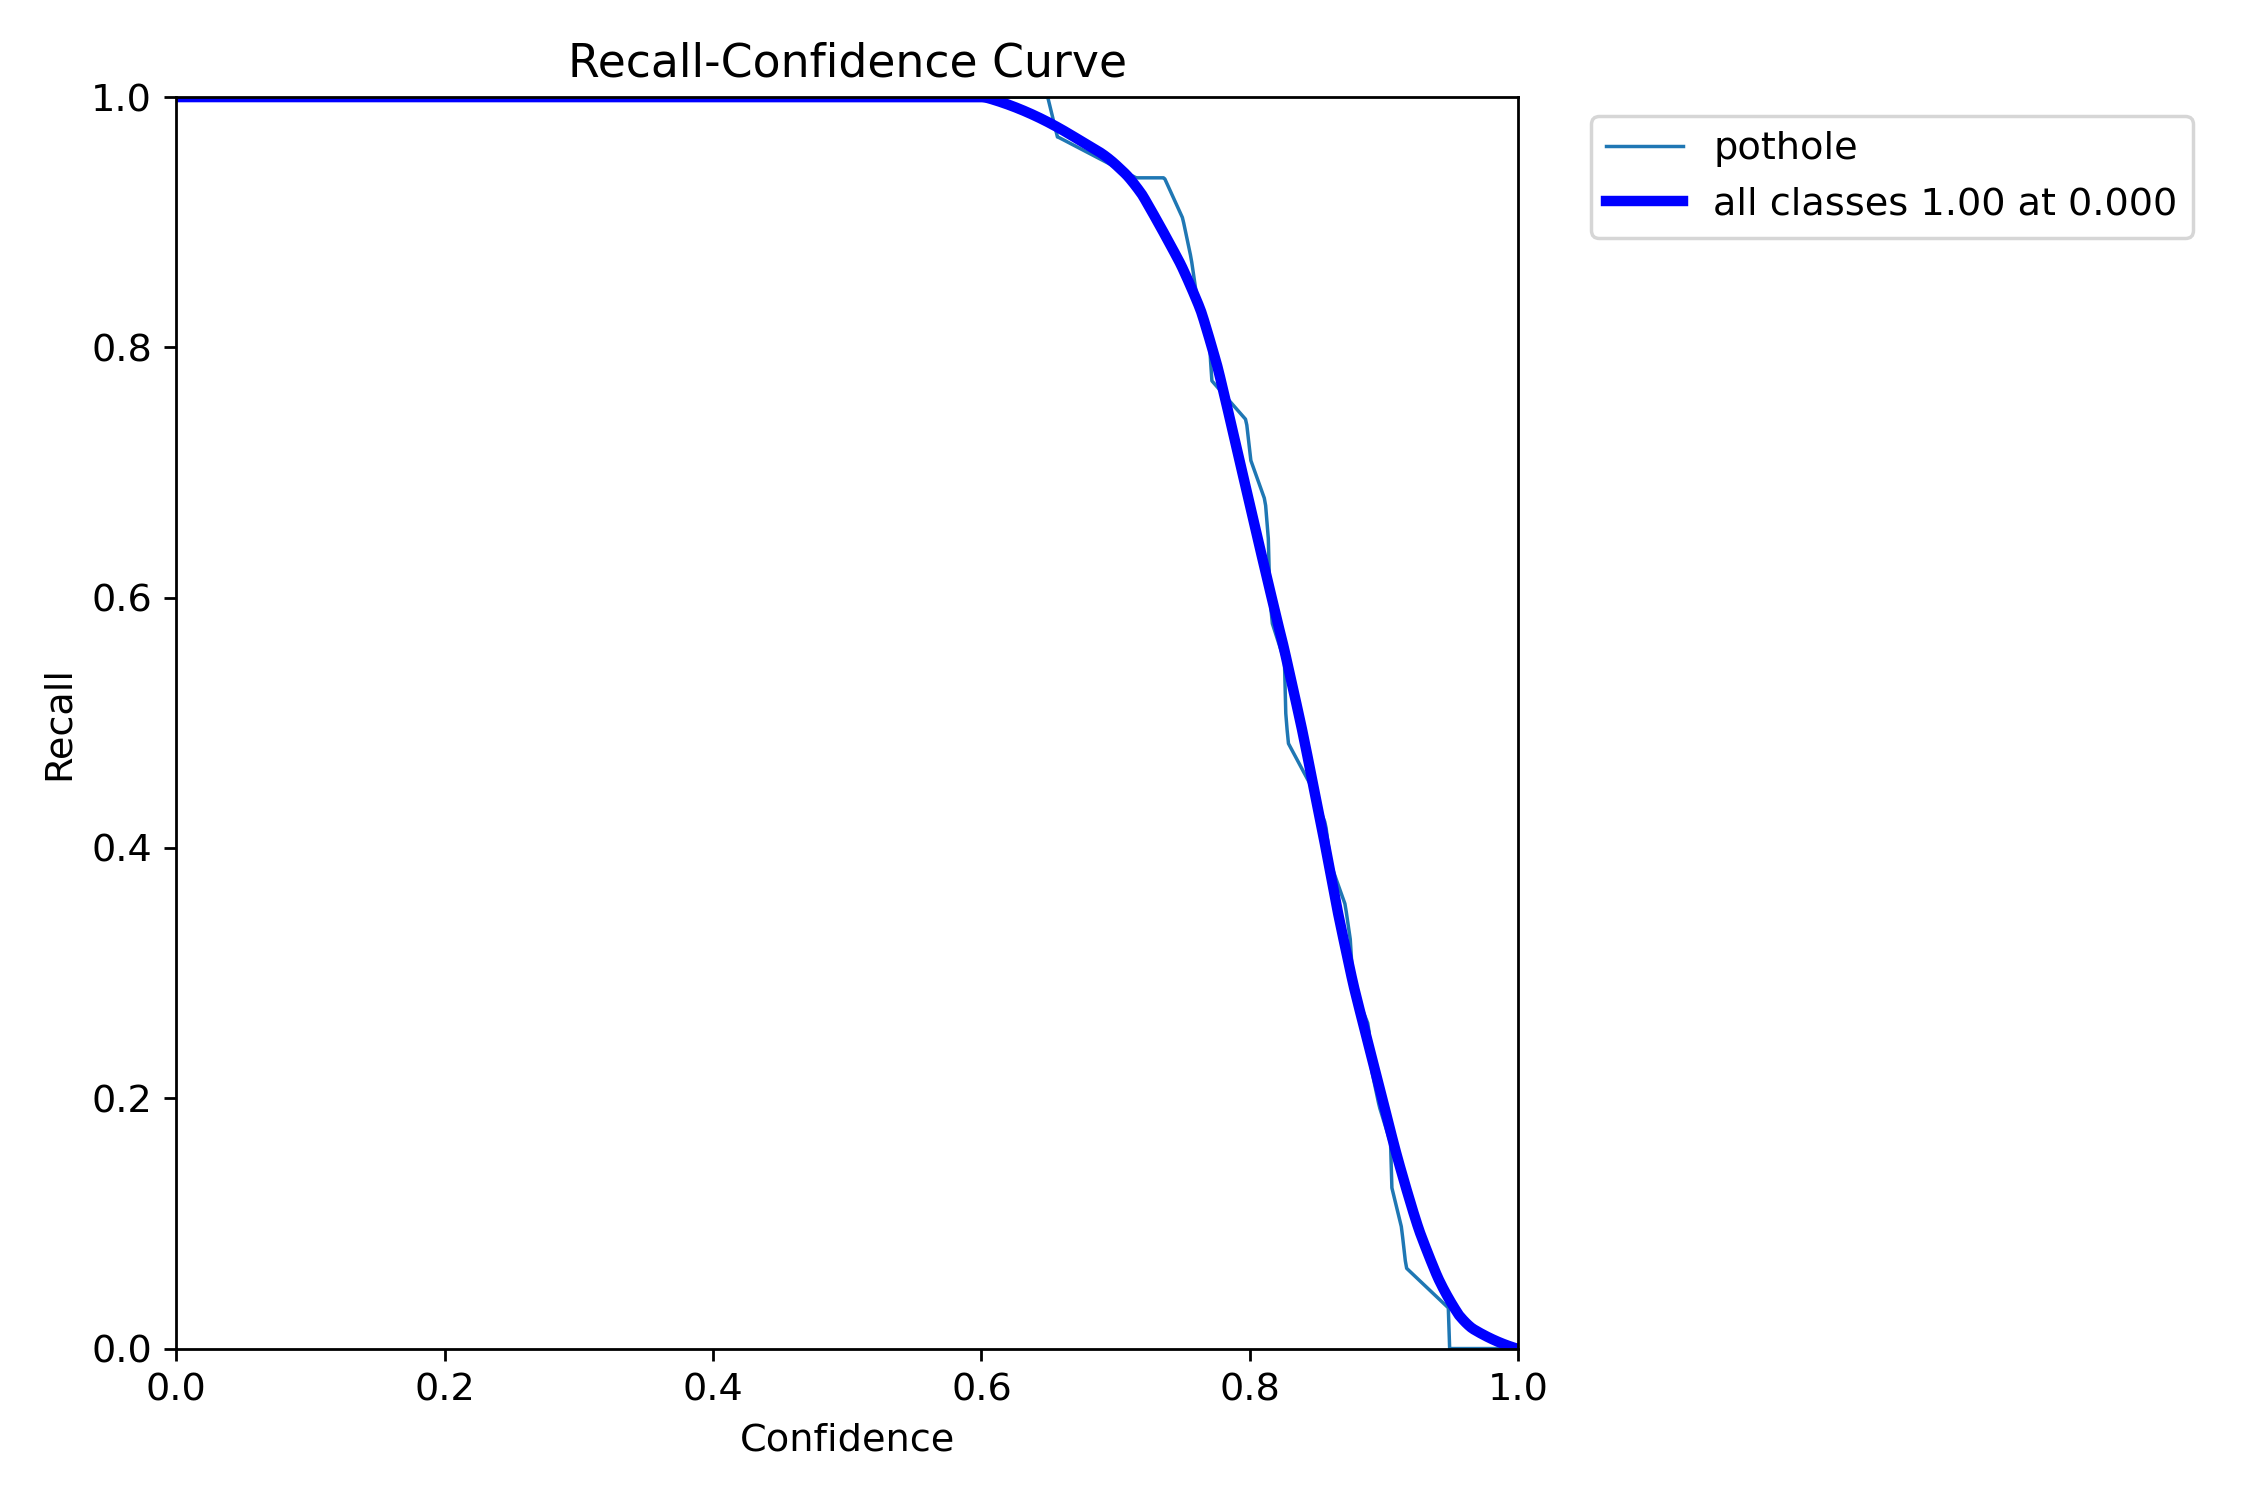

In [15]:
display(Image(filename="/content/runs/detect/Pothole_Project/YOLOv8/BoxR_curve.png"))

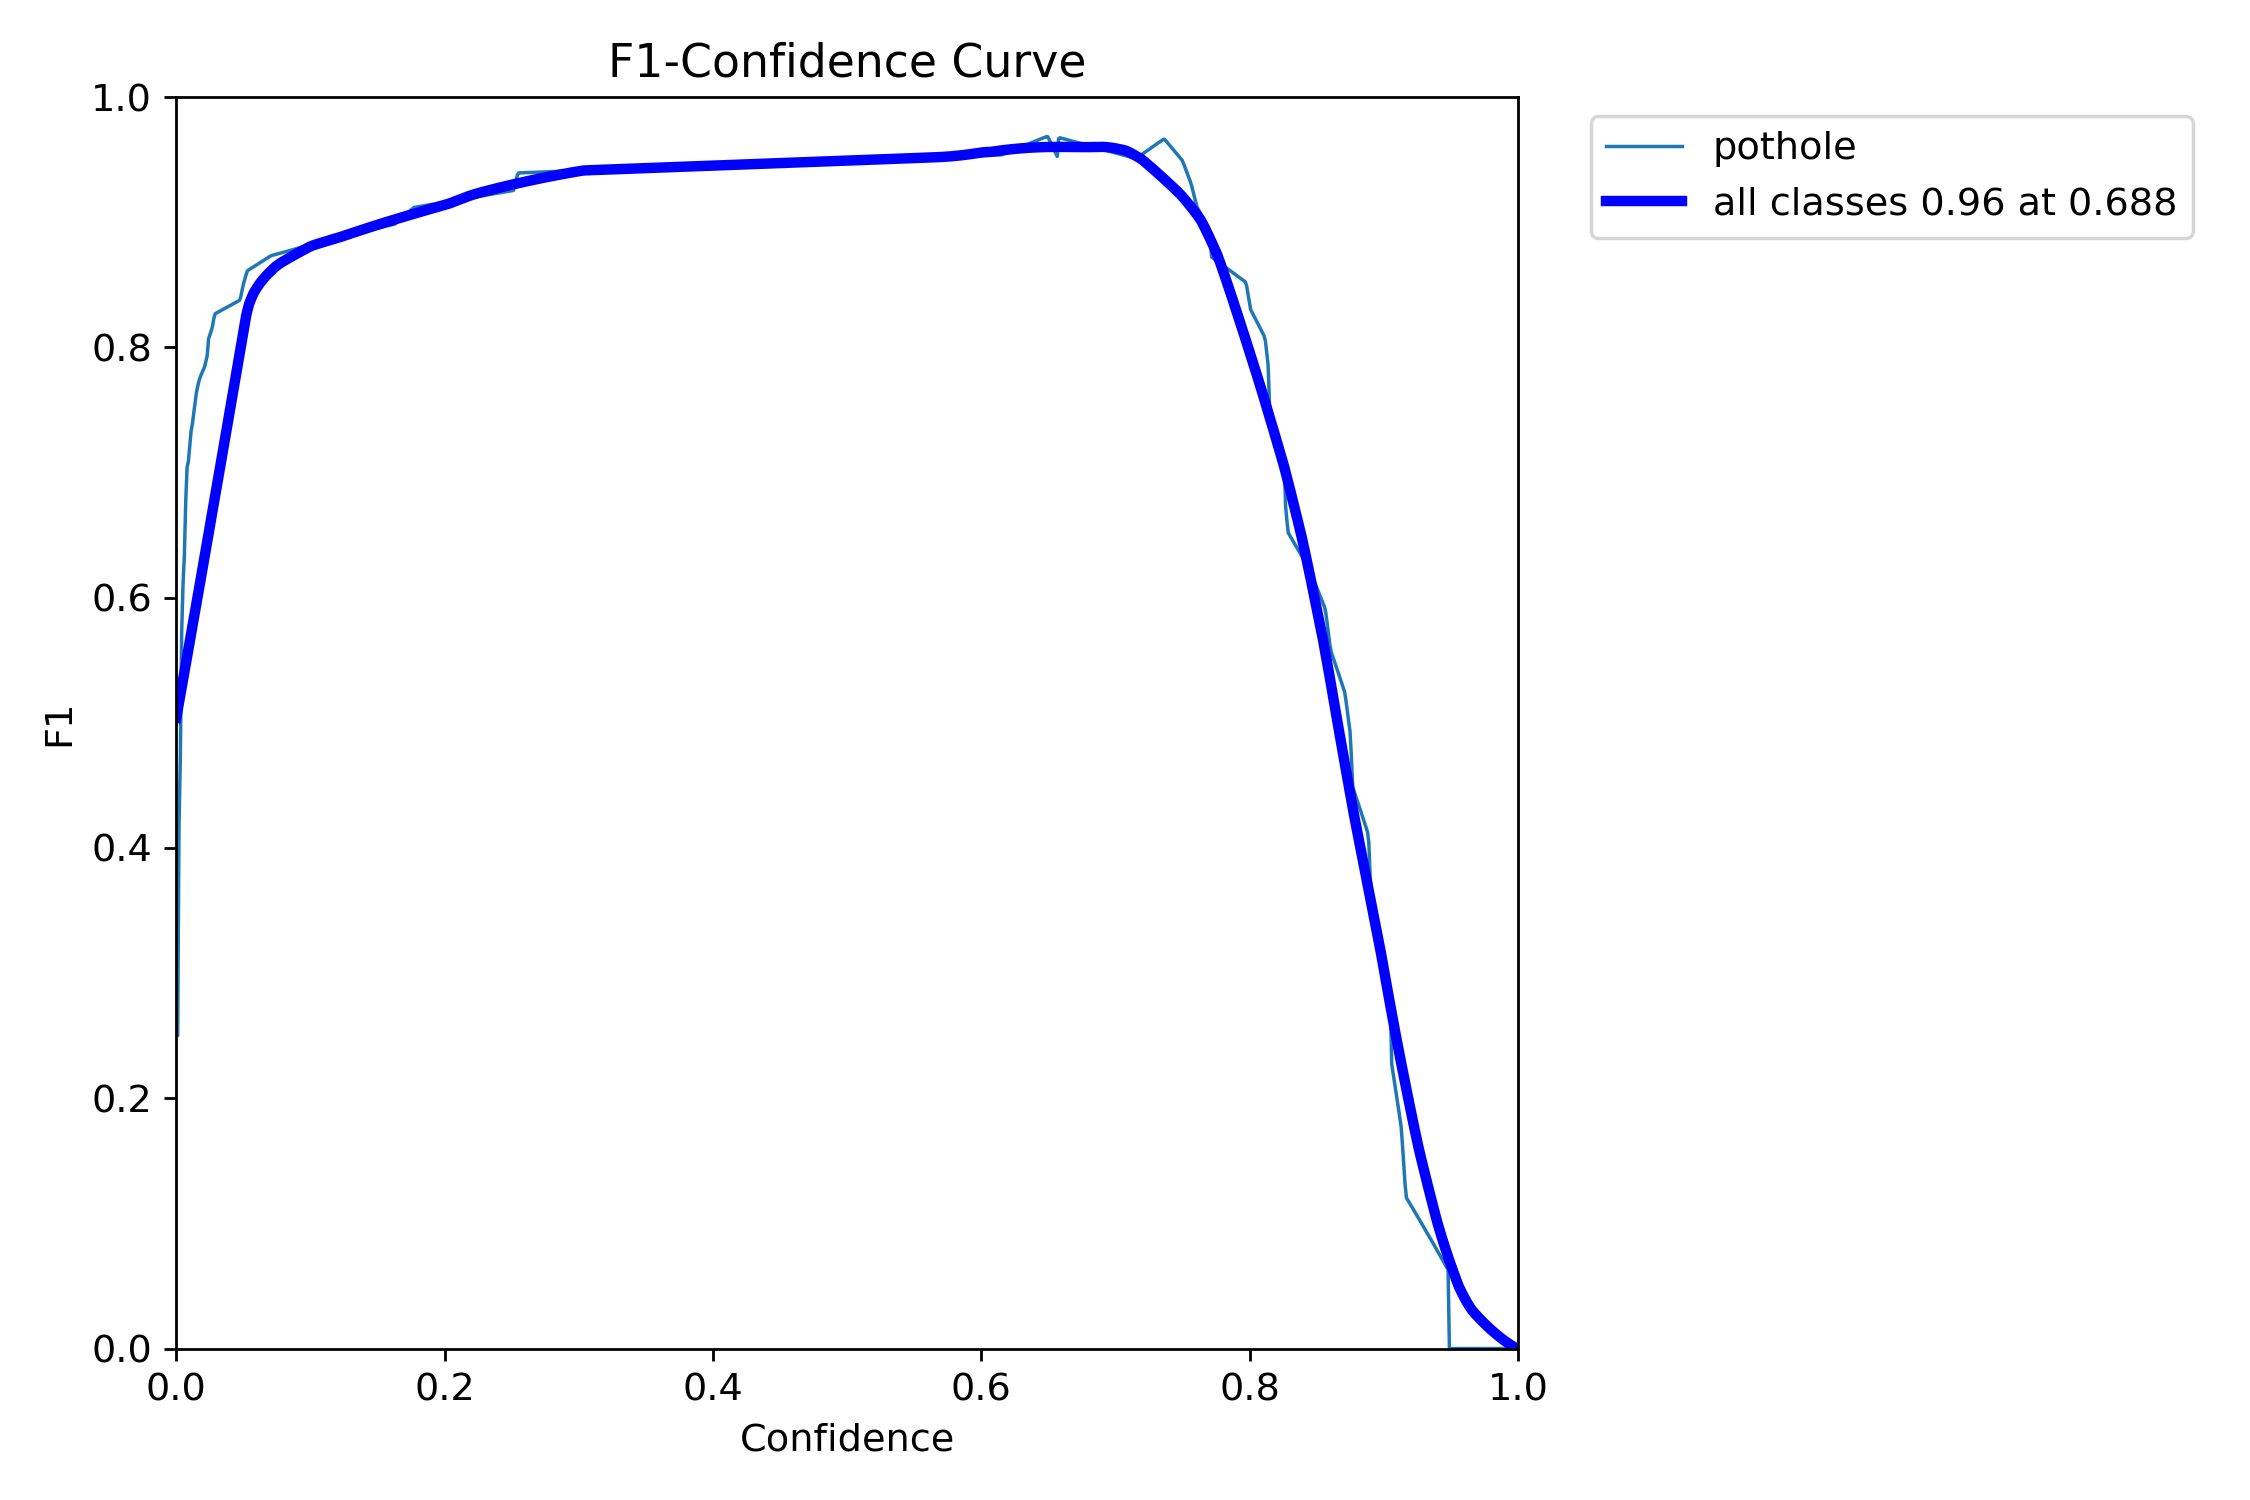

In [16]:
display(Image(filename="/content/runs/detect/Pothole_Project/YOLOv8/BoxF1_curve.png"))

In [17]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/Pothole_Project/YOLOv8/weights/best.pt")

model.predict(
    source="/content/dataset/test/images",
    save=True,
    conf=0.25
)


image 1/15 /content/dataset/test/images/1764136926660_aug_0_jpg.rf.537a6230c95a6fa3eca3e1776be8554b.jpg: 640x640 1 pothole, 17.9ms
image 2/15 /content/dataset/test/images/1764136926660_aug_4_jpg.rf.1e5b1cb92f1656840740a132249e928b.jpg: 640x640 1 pothole, 12.3ms
image 3/15 /content/dataset/test/images/1764136926692_aug_3_jpg.rf.c6d1c80aea8753ab99e3fafeff20f433.jpg: 640x640 1 pothole, 21.4ms
image 4/15 /content/dataset/test/images/1764136926715_aug_1_jpg.rf.d669e131e7dc5e10b32876426bcf67d6.jpg: 640x640 2 potholes, 10.6ms
image 5/15 /content/dataset/test/images/1764136926727_aug_0_jpg.rf.cb2124c5f285dedb1569b3b1d86a186c.jpg: 640x640 2 potholes, 14.4ms
image 6/15 /content/dataset/test/images/IMG_20250425_171710_aug_3_jpg.rf.69cebac1ed20ceafb873352259c2376f.jpg: 640x640 1 pothole, 19.8ms
image 7/15 /content/dataset/test/images/IMG_20250425_171802_aug_0_jpg.rf.65175938da3b495c9db7ce5b357db66f.jpg: 640x640 2 potholes, 16.0ms
image 8/15 /content/dataset/test/images/IMG_20250425_171935_aug_0_j

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[108, 117, 121],
         [ 86,  95,  99],
         [ 88,  97, 101],
         ...,
         [125, 128, 126],
         [ 93,  99,  94],
         [ 98, 104,  99]],
 
        [[164, 173, 177],
         [147, 156, 160],
         [160, 169, 173],
         ...,
         [ 99, 102, 100],
         [ 94,  99,  97],
         [ 86,  92,  87]],
 
        [[189, 198, 202],
         [132, 141, 145],
         [124, 133, 137],
         ...,
         [120, 122, 122],
         [108, 113, 112],
         [ 70,  75,  73]],
 
        ...,
 
        [[119, 125, 120],
         [105, 112, 107],
         [103, 108, 106],
         ...,
         [113, 113, 113],
         [ 88,  88,  88],
         [121, 121, 121]],
 
        [[118, 125, 120],
         [121, 131, 125],
         [ 92,  99,  96],
         ...,
    

In [18]:
import os

print(os.listdir("/content/runs/detect"))

['Pothole_Project', 'predict']


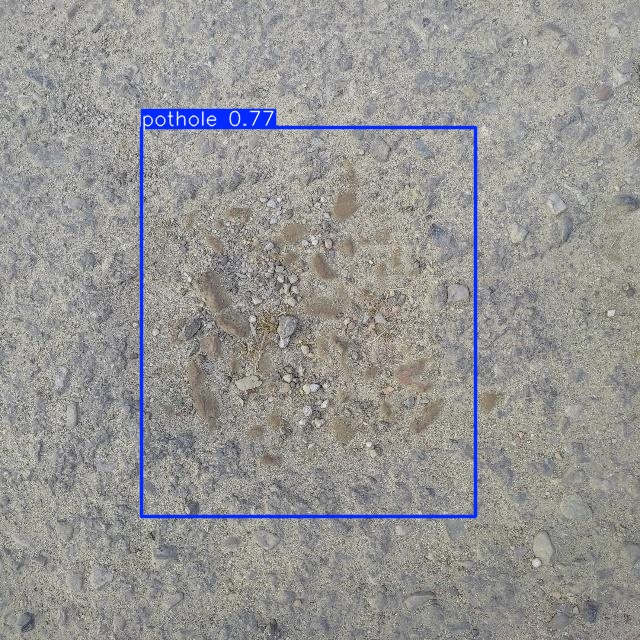

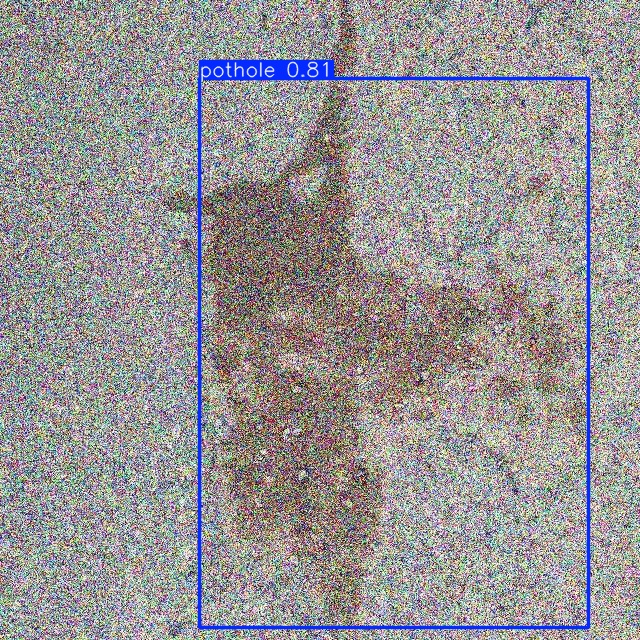

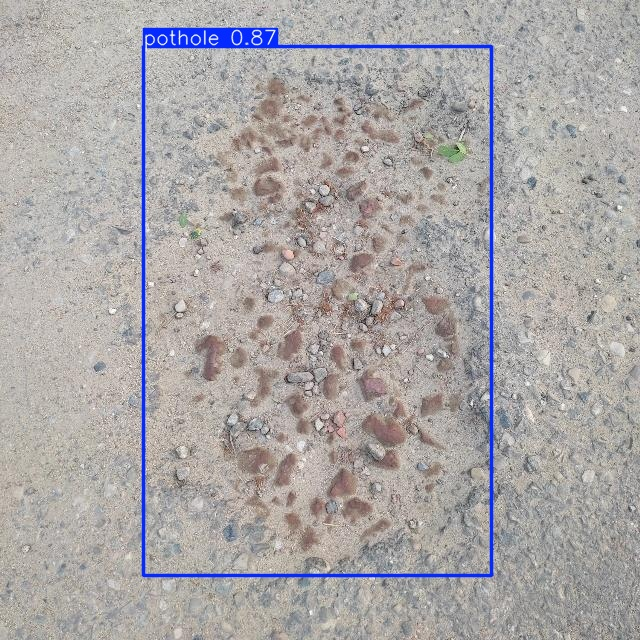

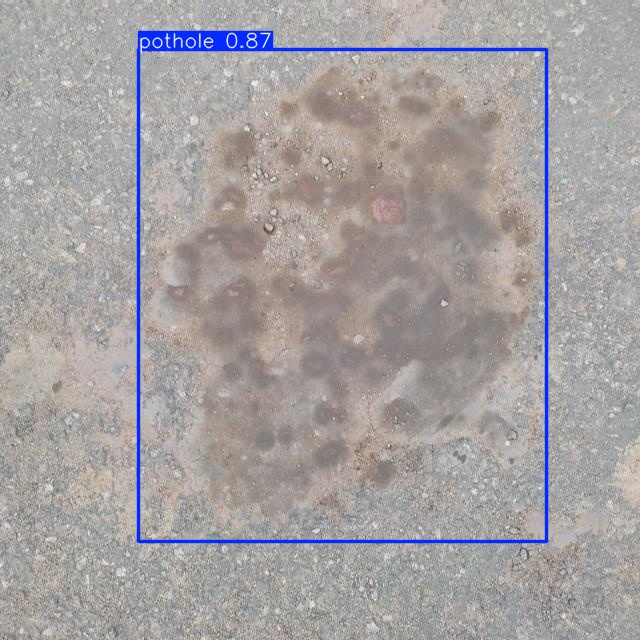

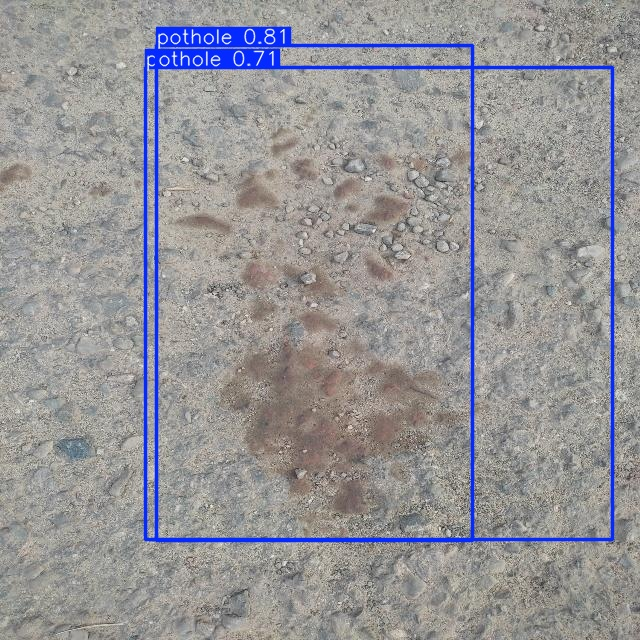

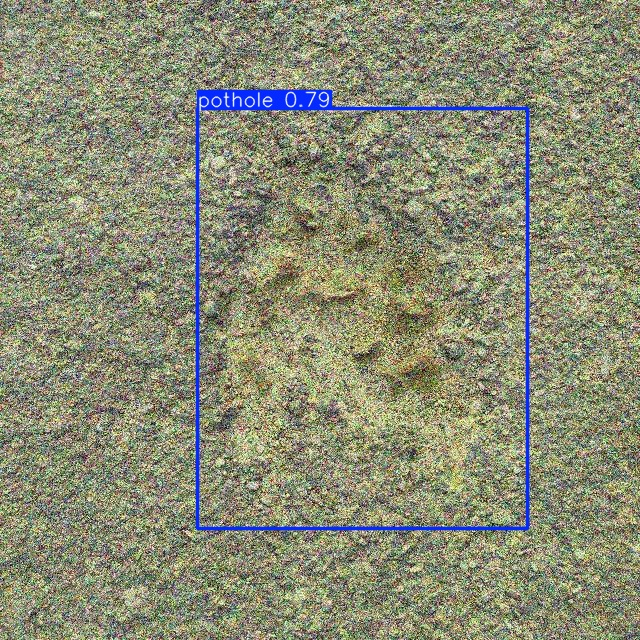

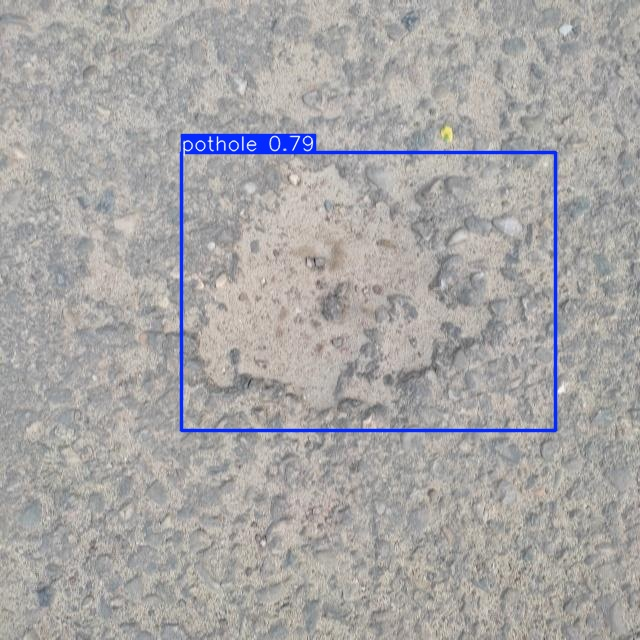

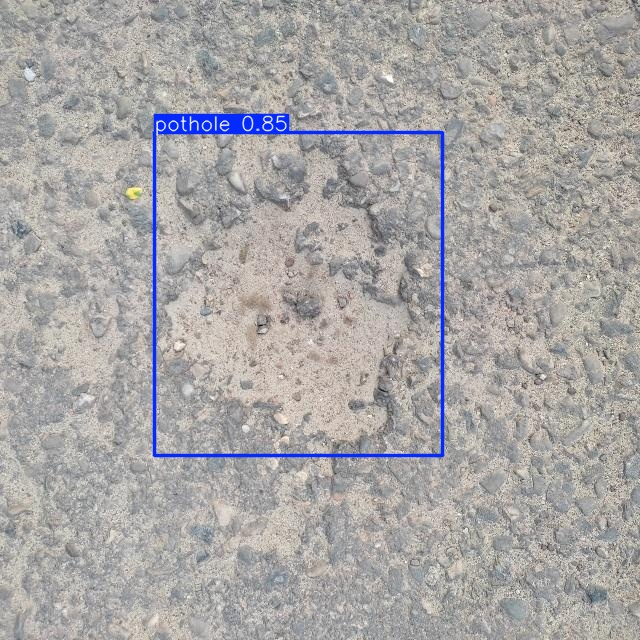

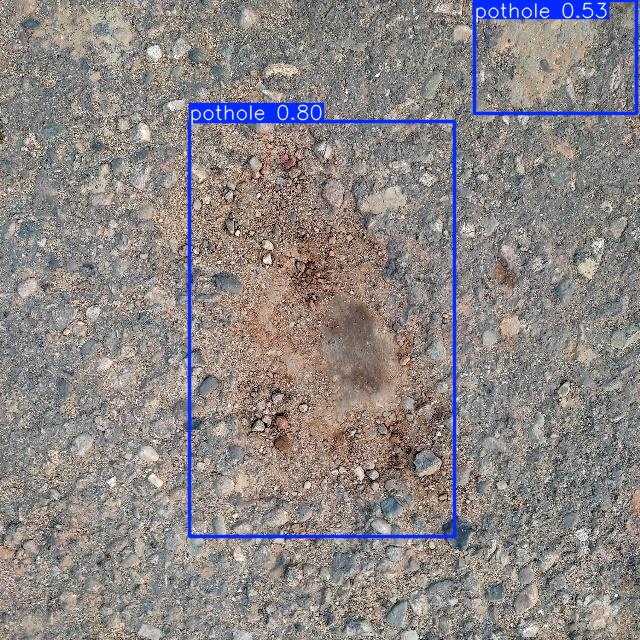

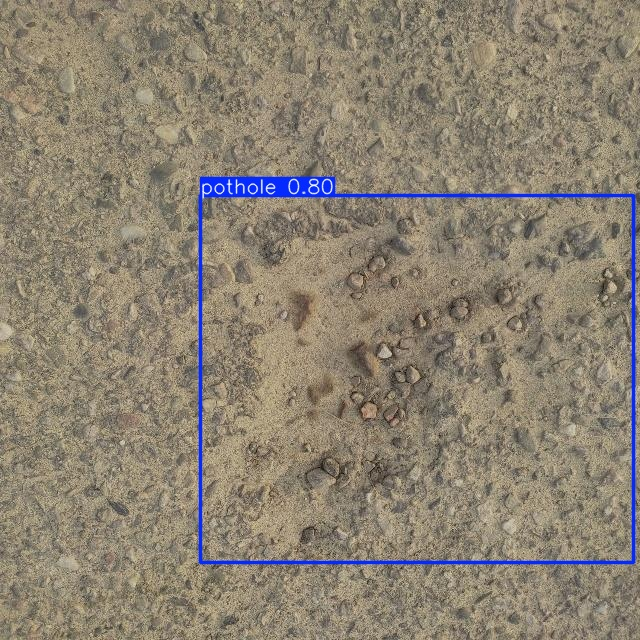

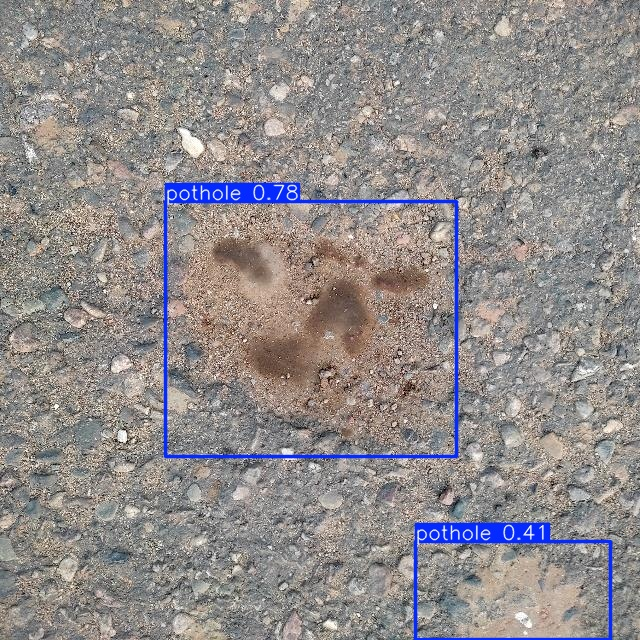

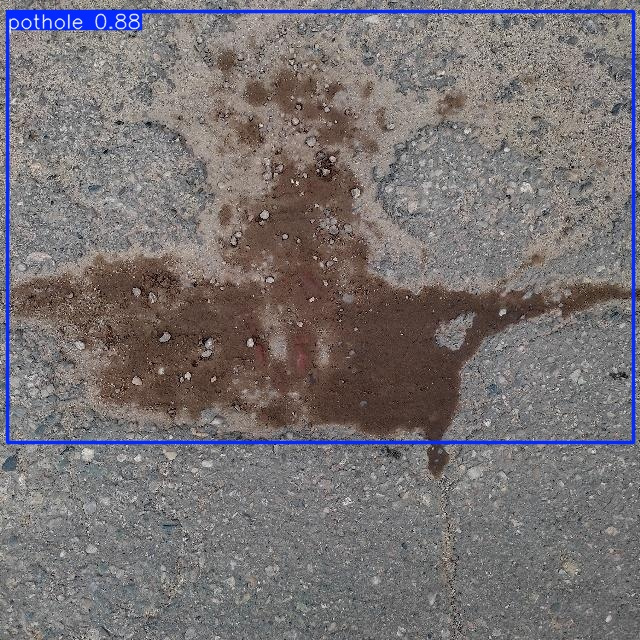

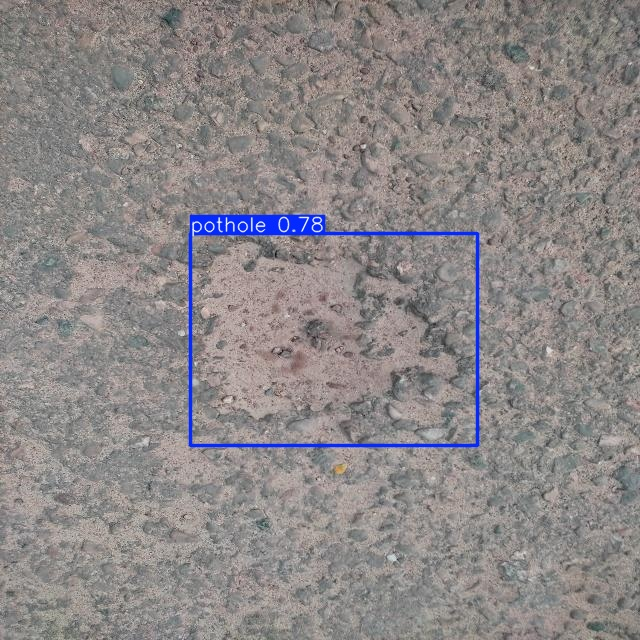

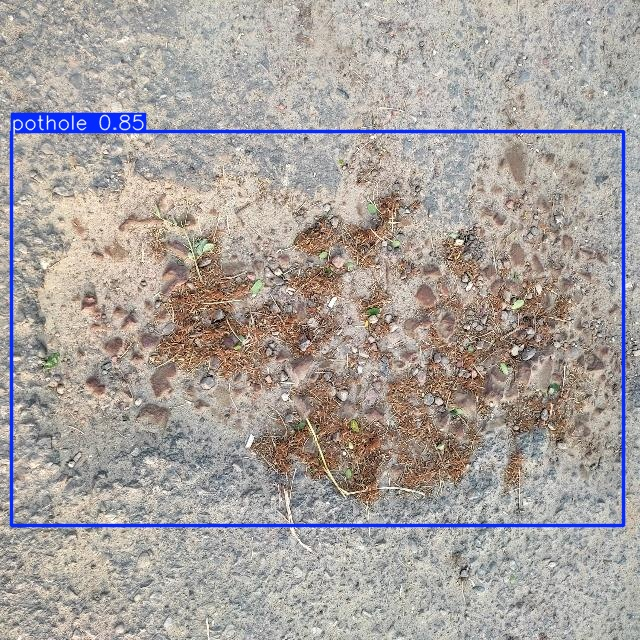

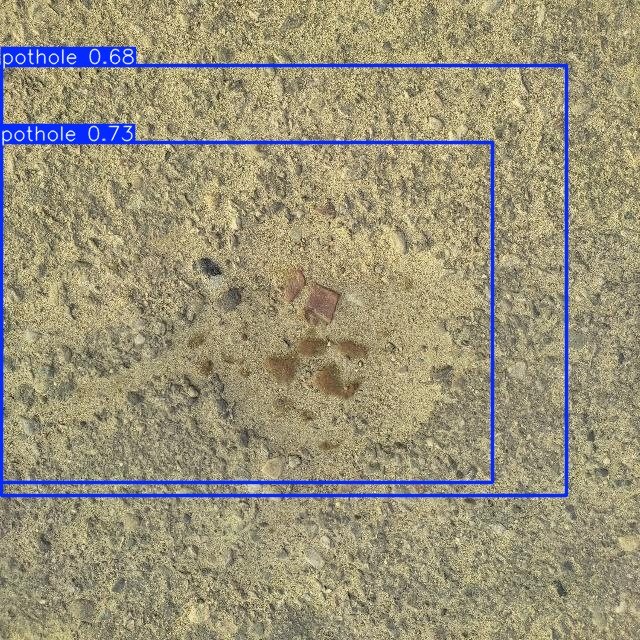

In [19]:
from IPython.display import Image, display
import os

pred_path = "/content/runs/detect/predict"

for img in os.listdir(pred_path):
    if img.endswith((".jpg", ".png", ".jpeg")):
        display(Image(filename=os.path.join(pred_path, img)))

In [20]:
!pip install -q streamlit pyngrok ultralytics pillow opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.9 MB/s eta 0:00:00


In [21]:
!find /content -name "best.pt"

/content/runs/detect/Pothole_Project/YOLOv8/weights/best.pt


In [30]:
%%writefile app.py

import streamlit as st
from ultralytics import YOLO
from PIL import Image

st.set_page_config(page_title="Pothole Detection", layout="wide")

st.title("🛣️ Pothole Detection System")
st.write("Upload a road image to detect potholes.")

model = YOLO("/content/runs/detect/Pothole_Project/YOLOv8/weights/best.pt")

uploaded_file = st.file_uploader("Upload Image", type=["jpg","jpeg","png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)

    st.image(image, caption="Original Image", use_container_width=1100)

    results = model.predict(image, conf=0.25)

    result_img = results[0].plot()

    st.image(result_img, caption="Detection Result", use_container_width=100)

Overwriting app.py


In [23]:
!pip install -q pyngrok streamlit

In [24]:
!ls

app.py	dataset  drive	runs  sample_data  yolo26n.pt  yolov8n.pt


In [25]:
from pyngrok import ngrok

ngrok.set_auth_token("3HbOTambUJ2YM04t4lJmZlIWozN_6PsvKPBVCQ6GUEHBQryFk")

In [26]:
from pyngrok import ngrok
import threading
import os

# Streamlit চালু
def run():
    os.system("streamlit run app.py --server.port 8501")

threading.Thread(target=run).start()

# ngrok tunnel তৈরি
public_url = ngrok.connect(8501)
print("Your Streamlit URL:")
print(public_url)

Your Streamlit URL:
NgrokTunnel: "https://stunner-synopses-decode.ngrok-free.dev" -> "http://localhost:8501"
